# CALIBRATION

Conversion factor (A → T): 2.021e-01 T/A
Slope uncertainty: 1.425e-03 T/A


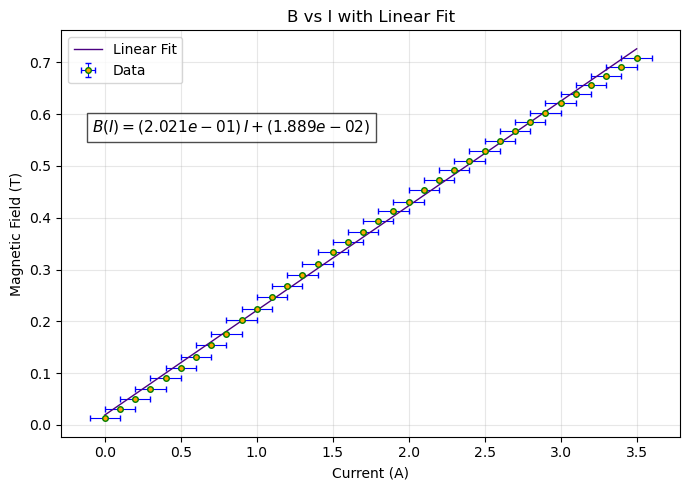

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --------------------------
# Data
# --------------------------
current = np.array([
0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,
2,2.1,2.2,2.3,2.4,2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5
])

avg_T = np.array([
0.01333333333,0.03066666667,0.04966666667,0.06966666667,0.09033333333,
0.1103333333,0.1316666667,0.154,0.1763333333,0.2016666667,0.2233333333,
0.246,0.2686666667,0.2903333333,0.3113333333,0.333,0.3533333333,0.3733333333,
0.3936666667,0.4123333333,0.4313333333,0.453,0.4723333333,0.492,0.51,
0.5296666667,0.548,0.5666666667,0.5853333333,0.603,0.6213333333,0.6393333333,
0.6563333333,0.6733333333,0.6906666667,0.708
])

std_T = np.array([
0.0005773502692,0.0005773502692,0.0005773502692,0.0005773502692,0.0005773502692,
0.001527525232,0.001154700538,0.001,0.0005773502692,0.0005773502692,
0.0005773502692,0.001,0.0005773502692,0.0005773502692,0.001527525232,
0,0.0005773502692,0.0005773502692,0.0005773502692,0.0005773502692,
0.001154700538,0.001,0.0005773502692,0.001,0,0.0005773502692,0.001,
0.0005773502692,0.0005773502692,0,0.0005773502692,0.0005773502692,
0.0005773502692,0.0005773502692,0.0005773502692,0.001
])

# --------------------------
# Linear Fit
# --------------------------
slope, intercept, r, p, stderr = linregress(current, avg_T)

print("Conversion factor (A → T): {:.3e} T/A".format(slope))
print("Slope uncertainty: {:.3e} T/A".format(stderr))

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(7,5))

plt.errorbar(
    current, avg_T,
    yerr=std_T,
    xerr=0.1,
    fmt='o',
    markersize=4,
    markerfacecolor='orange',
    markeredgecolor='green',
    ecolor='blue',
    elinewidth=0.8,
    capsize=2,
    label="Data"
)

plt.plot(
    current,
    slope * current + intercept,
    color='indigo',
    linewidth=1.0,
    label="Linear Fit"
)

# --------------------------
# Equation annotation (shifted down)
# --------------------------
eq_text = r"$B(I) = ({:.3e})\, I + ({:.3e})$".format(slope, intercept)

plt.text(
    0.05, 0.75,           # LOWER this second value to shift text further down
    eq_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.xlabel("Current (A)")
plt.ylabel("Magnetic Field (T)")
plt.title("B vs I with Linear Fit")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



Conversion factor (A → Gauss): 2.021e+03 G/A
Slope uncertainty: 1.425e+01 G/A


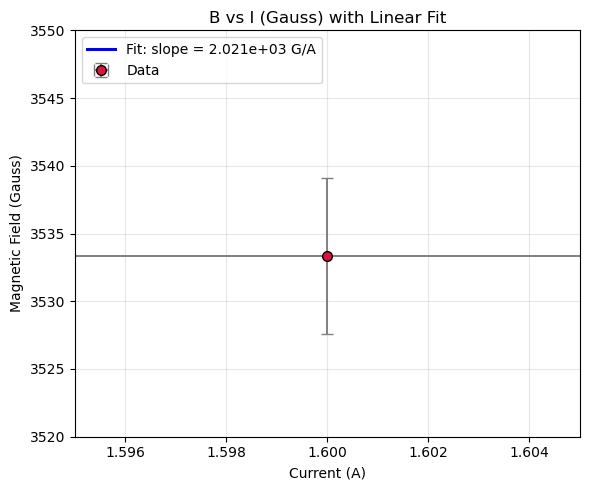

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --------------------------
# Data
# --------------------------
current = np.array([
0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,
2,2.1,2.2,2.3,2.4,2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5
])

# Avg magnetic field in Gauss (given)
avg_G = np.array([
133.3333333,306.6666667,496.6666667,696.6666667,903.3333333,
1103.333333,1316.666667,1540,1763.333333,2016.666667,2233.333333,
2460,2686.666667,2903.333333,3113.333333,3330,3533.333333,3733.333333,
3936.666667,4123.333333,4313.333333,4530,4723.333333,4920,5100,
5296.666667,5480,5666.666667,5853.333333,6030,6213.333333,6393.333333,
6563.333333,6733.333333,6906.666667,7080
])

# std was in Tesla — convert to Gauss by multiplying by 10^4
std_T = np.array([
0.0005773502692,0.0005773502692,0.0005773502692,0.0005773502692,0.0005773502692,
0.001527525232,0.001154700538,0.001,0.0005773502692,0.0005773502692,
0.0005773502692,0.001,0.0005773502692,0.0005773502692,0.001527525232,
0,0.0005773502692,0.0005773502692,0.0005773502692,0.0005773502692,
0.001154700538,0.001,0.0005773502692,0.001,0,0.0005773502692,0.001,
0.0005773502692,0.0005773502692,0,0.0005773502692,0.0005773502692,
0.0005773502692,0.0005773502692,0.0005773502692,0.001
])

std_G = std_T * 1e4    # convert to Gauss

# --------------------------
# Linear Fit (Gauss vs A)
# --------------------------
slope, intercept, r, p, stderr = linregress(current, avg_G)

print("Conversion factor (A → Gauss): {:.3e} G/A".format(slope))
print("Slope uncertainty: {:.3e} G/A".format(stderr))

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(6,5))

plt.errorbar(
    current, avg_G,
    yerr=std_G,
    xerr=0.1,
    fmt='o',
    markersize=7,
    markerfacecolor='crimson',
    markeredgecolor='black',
    ecolor='gray',
    elinewidth=1.4,
    capsize=4,
    label="Data"
)

plt.plot(
    current,
    slope * current + intercept,
    color='blue',
    linewidth=2.2,
    label=f"Fit: slope = {slope:.3e} G/A"
)

plt.xlabel("Current (A)")
plt.ylabel("Magnetic Field (Gauss)")
plt.title("B vs I (Gauss) with Linear Fit")
plt.grid(True, alpha=0.3)
plt.xlim(1.595,1.605)
plt.ylim(3520,3550)
plt.legend()
plt.tight_layout()
plt.show()


# GUOYS METHOD

## ROD 1

Rod 1: slope = 4.222e-06 ± 1.699e-07 kg/T²


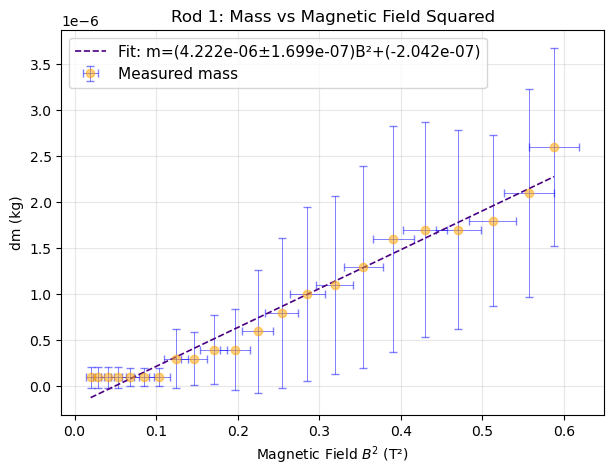

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# -----------------------------
# DATA
# -----------------------------
I = np.array([0,0.15,0.3,0.45,0.6,0.75,0.9,1.05,1.2,1.35,1.5,1.65,1.8,1.95,2.1,2.25,2.4,2.55,2.7,2.85,3.0,3.15,3.3,3.45,3.6,3.7])
m_avg_g = np.array([0.0,0.0,0.0,0.0,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0003,0.0003,0.0004,0.0004,0.0006,0.0008,0.0010,0.0011,0.0013,0.0016,0.0017,0.0017,0.0018,0.0021,0.0026])
m_std_g = np.array([0.0,0.0,0.0,0.0,0.00011547,0.00011547,0.00011547,0.00011547,0.0001,0.0001,0.0001,0.00032146,0.00028868,0.00037859,0.00043589,0.00066583,0.00081445,0.00094516,0.00096437,0.00109697,0.00122882,0.00116762,0.00108167,0.00092916,0.00112398,0.00107858])

least_count = 1e-7
m_avg = m_avg_g*1e-3
m_std = np.maximum(m_std_g*1e-3, least_count)

# -----------------------------
# Magnetic field
# -----------------------------
a,b = 0.2021,0.01889
B = a*I + b
dB = a*0.1
B2 = B**2
dB2 = 2*B*dB

mask = m_avg>0
B2, m_avg, m_std, dB2 = B2[mask], m_avg[mask], m_std[mask], dB2[mask]

# -----------------------------
# Linear fit with error
# -----------------------------
fit = linregress(B2, m_avg)
slope, intercept, slope_err = fit.slope, fit.intercept, fit.stderr
print(f"Rod 1: slope = {slope:.3e} ± {slope_err:.3e} kg/T²")

B2_fit = np.linspace(min(B2), max(B2),300)
m_fit = slope*B2_fit + intercept

plt.figure(figsize=(7,5))
plt.errorbar(B2,m_avg,xerr=dB2,yerr=m_std,fmt='o',color='orange',ecolor='blue',capsize=3,elinewidth=0.7,alpha=0.5,label="Measured mass")
plt.plot(B2_fit,m_fit,'--',color='indigo',linewidth=1.2,label=f"Fit: m=({slope:.3e}±{slope_err:.3e})B²+({intercept:.3e})")
plt.xlabel("Magnetic Field $B^2$ (T²)")
plt.ylabel("dm (kg)")
plt.title("Rod 1: Mass vs Magnetic Field Squared")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.savefig("Rod1.png", dpi =300)


## ROD 2

Rod 2: slope = 5.215e-05 ± 6.725e-07 kg/T²


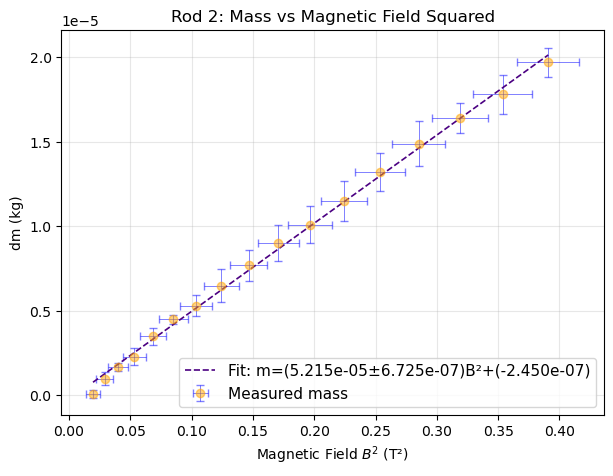

In [6]:
# Similar procedure for Rod 2
I = np.array([0,0.15,0.3,0.45,0.6,0.75,0.9,1.05,1.2,1.35,1.5,1.65,1.8,1.95,2.1,2.25,2.4,2.55,2.7,2.85,3.0])
m1 = np.array([0,0,0,0,0,0.0006,0.0014,0.0018,0.003,0.0042,0.0046,0.0054,0.0067,0.0078,0.0089,0.0102,0.012,0.0135,0.0155,0.0165,0.0187])
m2 = np.array([0,0,0,0,0,0.0010,0.0018,0.0023,0.0035,0.0045,0.0055,0.0067,0.0079,0.0092,0.0104,0.0119,0.0135,0.0149,0.0164,0.0183,0.0201])
m3 = np.array([0,0,0,0,0.0004,0.0014,0.0018,0.0028,0.0040,0.0047,0.0058,0.0073,0.0085,0.0099,0.0110,0.0125,0.0142,0.0162,0.0173,0.0186,0.0203])

least_count = 1e-4
m_avg_g = np.round((m1+m2+m3)/3,4)
m_std_g = np.maximum(np.std(np.vstack([m1,m2,m3]),axis=0,ddof=1),least_count)
m_avg, m_std = m_avg_g*1e-3, m_std_g*1e-3

a,b=0.2021,0.01889
B=a*I+b
dB=a*0.1
B2=B**2
dB2=2*B*dB

mask = m_avg>0
B2,m_avg,m_std,dB2 = B2[mask],m_avg[mask],m_std[mask],dB2[mask]

fit = linregress(B2,m_avg)
slope,intercept,slope_err = fit.slope,fit.intercept,fit.stderr
print(f"Rod 2: slope = {slope:.3e} ± {slope_err:.3e} kg/T²")

B2_fit = np.linspace(min(B2),max(B2),300)
m_fit = slope*B2_fit+intercept

plt.figure(figsize=(7,5))
plt.errorbar(B2,m_avg,xerr=dB2,yerr=m_std,fmt='o',color='orange',ecolor='blue',capsize=3,elinewidth=0.7,alpha=0.5,label="Measured mass")
plt.plot(B2_fit,m_fit,'--',color='indigo',linewidth=1.2,label=f"Fit: m=({slope:.3e}±{slope_err:.3e})B²+({intercept:.3e})")
plt.xlabel("Magnetic Field $B^2$ (T²)")
plt.ylabel("dm (kg)")
plt.title("Rod 2: Mass vs Magnetic Field Squared")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.savefig("Rod2.png", dpi =300)

## ROD 3

Rod 3: slope = 3.168e-05 ± 4.966e-07 kg/T²


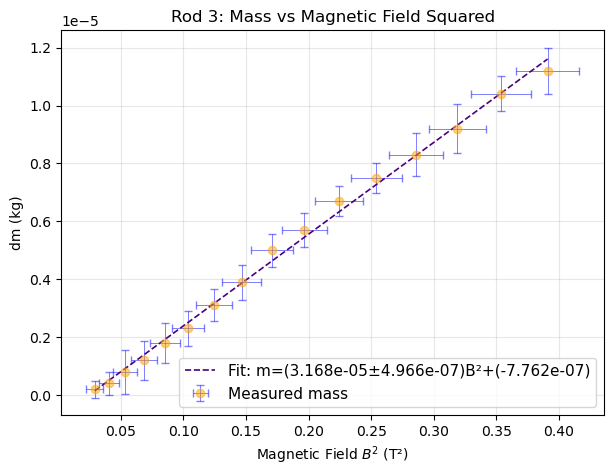

In [7]:
I = np.array([0,0.15,0.3,0.45,0.6,0.75,0.9,1.05,1.2,1.35,1.5,1.65,1.8,1.95,2.1,2.25,2.4,2.55,2.7,2.85,3.0])
m1 = np.array([0,0,0,0,0,0,0.0004,0.0008,0.0015,0.0023,0.0029,0.0036,0.0045,0.0053,0.0060,0.0073,0.0081,0.0090,0.0102,0.0110,0.0120])
m2 = np.array([0,0,0,0,0,0,0,0,0.0004,0.0010,0.0017,0.0025,0.0033,0.0043,0.0050,0.0063,0.0071,0.0083,0.0089,0.0098,0.0112])
m3 = np.array([0,0,0,0,0,0.0005,0.0008,0.0015,0.0016,0.0020,0.0023,0.0032,0.0039,0.0053,0.0060,0.0065,0.0073,0.0075,0.0086,0.0103,0.0104])

least_count=1e-4
m_avg_g=np.round((m1+m2+m3)/3,4)
m_std_g=np.maximum(np.std(np.vstack([m1,m2,m3]),axis=0,ddof=1),least_count)
m_avg,m_std=m_avg_g*1e-3,m_std_g*1e-3

a,b=0.2021,0.01889
B=a*I+b
dB=a*0.1
B2=B**2
dB2=2*B*dB

mask=m_avg>0
B2,m_avg,m_std,dB2=B2[mask],m_avg[mask],m_std[mask],dB2[mask]

fit=linregress(B2,m_avg)
slope,intercept,slope_err=fit.slope,fit.intercept,fit.stderr
print(f"Rod 3: slope = {slope:.3e} ± {slope_err:.3e} kg/T²")

B2_fit=np.linspace(min(B2),max(B2),300)
m_fit=slope*B2_fit+intercept

plt.figure(figsize=(7,5))
plt.errorbar(B2,m_avg,xerr=dB2,yerr=m_std,fmt='o',color='orange',ecolor='blue',capsize=3,elinewidth=0.7,alpha=0.5,label="Measured mass")
plt.plot(B2_fit,m_fit,'--',color='indigo',linewidth=1.2,label=f"Fit: m=({slope:.3e}±{slope_err:.3e})B²+({intercept:.3e})")
plt.xlabel("Magnetic Field $B^2$ (T²)")
plt.ylabel("dm (kg)")
plt.title("Rod 3: Mass vs Magnetic Field Squared")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.savefig("Rod3.png", dpi =300)

## ROD 4

Rod 4: slope = 6.074e-06 ± 1.850e-07 kg/T²


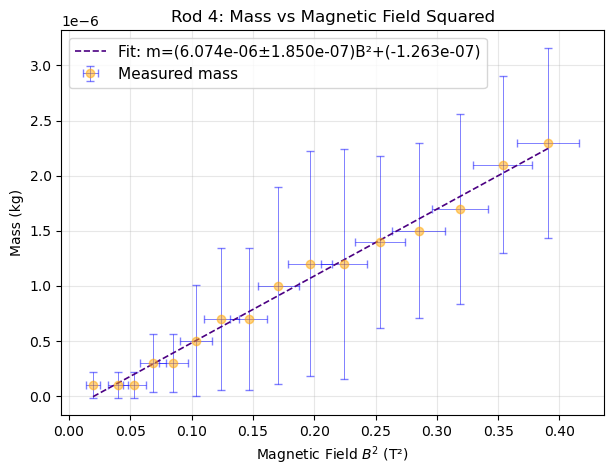

In [8]:
I = np.array([0,0.15,0.3,0.45,0.6,0.75,0.9,1.05,1.2,1.35,1.5,1.65,1.8,1.95,2.1,2.25,2.4,2.55,2.7,2.85,3.0])
m1=np.array([0,0,0,0,0,0,0,0,0.0004,0.0004,0.0004,0.0012,0.0012,0.0015,0.0019,0.0019,0.0019,0.0021,0.0025,0.0029,0.0032])
m2=np.array([0,0,0,0.0001,0.0002,0.0001,0.0002,0.0002,0.0005,0.0005,0.0010,0.0010,0.0010,0.0016,0.0016,0.0017,0.0018,0.0018,0.0019,0.0020,0.0021])
m3=np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0005,0.0006,0.0008,0.0013,0.0015])

least_count=1e-4
m_avg_g=np.round((m1+m2+m3)/3,4)
m_std_g=np.maximum(np.std(np.vstack([m1,m2,m3]),axis=0,ddof=1),least_count)
m_avg,m_std=m_avg_g*1e-3,m_std_g*1e-3

a,b=0.2021,0.01889
B=a*I+b
dB=a*0.1
B2=B**2
dB2=2*B*dB

mask=m_avg>0
B2,m_avg,m_std,dB2=B2[mask],m_avg[mask],m_std[mask],dB2[mask]

fit=linregress(B2,m_avg)
slope,intercept,slope_err=fit.slope,fit.intercept,fit.stderr
print(f"Rod 4: slope = {slope:.3e} ± {slope_err:.3e} kg/T²")

B2_fit=np.linspace(min(B2),max(B2),300)
m_fit=slope*B2_fit+intercept

plt.figure(figsize=(7,5))
plt.errorbar(B2,m_avg,xerr=dB2,yerr=m_std,fmt='o',color='orange',ecolor='blue',capsize=3,elinewidth=0.7,alpha=0.5,label="Measured mass")
plt.plot(B2_fit,m_fit,'--',color='indigo',linewidth=1.2,label=f"Fit: m=({slope:.3e}±{slope_err:.3e})B²+({intercept:.3e})")
plt.xlabel("Magnetic Field $B^2$ (T²)")
plt.ylabel("Mass (kg)")
plt.title("Rod 4: Mass vs Magnetic Field Squared")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.savefig("Rod4.png", dpi =300)

# Susceptibility

In [78]:
import numpy as np, math

g = 9.80665
mu0 = 4*math.pi*1e-7

# slopes (kg/T^2) and uncertainties
slopes = np.array([4.222e-6, 5.215e-5, 3.168e-5, 6.074e-6])
s_err = np.array([1.699e-7, 6.725e-7, 4.966e-7, 1.850e-7])

# diameters (mm) and uncertainty in diameter (mm)
d_mm = np.array([3.9, 8.0, 6.38, 4.0])
dd_mm = 0.01

d = d_mm * 1e-3
dd = dd_mm * 1e-3

# area and area uncertainty
A = np.pi * d**2 / 4.0
dA = (np.pi * d / 2.0) * dd

# susceptibility
chi = 2.0 * slopes * g * mu0 / A

# combined error from slope and area
chi_err = chi * np.sqrt((s_err / slopes)**2 + (dA / A)**2)

for i in range(4):
    print(f"Rod {i+1}: A = {A[i]:.6e} ± {dA[i]:.6e} m²")
    print(f"  chi = {chi[i]:.6e} ± {chi_err[i]:.6e}\n")


Rod 1: A = 1.194591e-05 ± 6.126106e-08 m²
  chi = 8.710833e-06 ± 3.533726e-07

Rod 2: A = 5.026548e-05 ± 1.256637e-07 m²
  chi = 2.557084e-05 ± 3.358881e-07

Rod 3: A = 3.196916e-05 ± 1.002168e-07 m²
  chi = 2.442387e-05 ± 3.904371e-07

Rod 4: A = 1.256637e-05 ± 6.283185e-08 m²
  chi = 1.191312e-05 ± 3.677028e-07

